In [1]:
from components.other_utilities.models_to_train import ResNetPLModel
m=ResNetPLModel(num_classes=10, resnet_version='resnet20', lr=0.01, )
model_trainable_param_count = sum(p.numel() for p in m.parameters() if p.requires_grad)

In [9]:
from torchvision.transforms import transforms
from components.other_utilities.datasets import FasterSVHN

# train on svhn
data_folder = r'data'
dataset = [
    FasterSVHN(
        root=data_folder + '/SVHN', split=s,
        transform=transforms.Compose([
            transforms.Resize(32),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.4377, 0.4438, 0.4728],
                std=[0.1980, 0.2010, 0.1970]
            ),
    ])
) for s in ['train', 'test']]

In [14]:
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

# Unpack datasets
train_dataset, test_dataset = dataset

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
)

# PyTorch Lightning Training (Recommended)
trainer = pl.Trainer(
    max_epochs=50,
    accelerator='gpu',
    log_every_n_steps=50,

)

# Train the model
trainer.fit(m, train_loader, test_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode 
--------------------------------------------------------
0 | model    | ResNet20           | 272 K  | train
1 | loss_fn  | CrossEntropyLoss   | 0      | train
2 | accuracy | MulticlassAccuracy | 0      | train
--------------------------------------------------------
272 K     Trainable params
0         Non-trainable params
272 K     Total params
1.090     Total estimated model params size (MB)
78        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# hybrid
df_wz = pd.read_csv('wz_base.csv').groupby('round_id').mean().reset_index()
df_global = pd.read_csv('auc_base.csv')
temp = (8*1024*1024/model_trainable_param_count)

In [21]:
(df_wz[['mape%']].values).mean()

29.020593750000003

In [22]:
(df_wz[['mbytes_recived']].values).mean()*temp

1.0029246993878878

In [23]:
(df_wz[['mbytes_sent_to_worker']].values + df_wz[['mbytes_recived']].values).mean()*temp

2.7880729856119855

In [51]:
# all out
df_wz = pd.read_csv('wz.csv').groupby('round_id').mean().reset_index()
(df_wz[['mape%']].values).mean(), (df_wz[['mbytes_recived']].values).mean() * temp, (df_wz[['mbytes_sent_to_worker']].values + df_wz[['mbytes_recived']].values).mean() * temp

(38.38765624999999, 2.1977483356210112, 4.232075182708562)

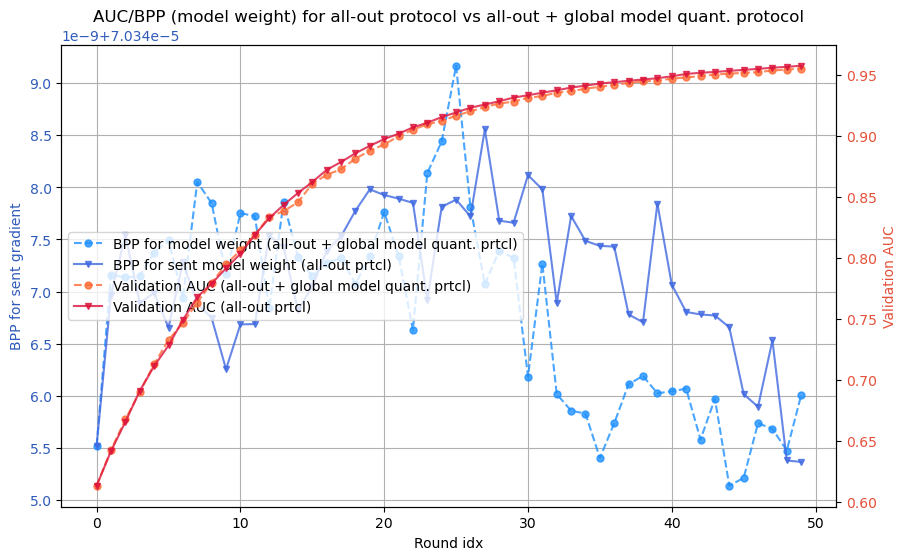

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

name = '1Bit Hybrid prtcl'
name_base = 'Basic Entropy prtcl'

model_size = 11_191_262

plt.figure(figsize=(10, 6))
ax1 = plt.gca()
temp = [name.replace('prtcl', 'protocol'), name_base.replace('prtcl', 'protocol')]
ax1.set_title(f'AUC/BPP (model weight) for {temp[0]} vs {temp[1]}')

ax2 = ax1.twinx()

df_wz = pd.read_csv('wz_base.csv').groupby('round_id').mean().reset_index()
df_global = pd.read_csv('auc_base.csv')
ax2.plot(df_wz['round_id'], df_global['val_auc'].apply(lambda x: eval(x[6:])).values[:-1],
         label=f'Validation AUC ({name_base})', color='#FF6B35', linestyle='dashed', alpha=0.8, marker='o', markersize=5)
ax1.plot(df_wz['round_id'], df_wz['mbytes_sent_for_aggre']*8/model_size*5,
         label=f'BPP for model weight ({name_base})', color='#1E90FF', linestyle='dashed', alpha=0.8, marker='o',markersize=5)

df_wz = pd.read_csv('wz.csv').groupby('round_id').mean().reset_index()
df_global = pd.read_csv('auc.csv')
ax2.plot(df_wz['round_id'], df_global['val_auc'].apply(lambda x: eval(x[6:])).values[:-1],
         label=f'Validation AUC ({name})', color='#DC143C', alpha=0.8, marker='v', markersize=5)
ax1.plot(df_wz['round_id'], df_wz['mbytes_sent_for_aggre']*8/model_size*5,
         label=f'BPP for sent model weight ({name})', color='#4169E1', alpha=0.8, marker='v', markersize=5)

# Set separate y-axis labels and colors
ax1.set_ylabel('BPP for sent gradient', color='#2E5BBA')
ax2.set_ylabel('Validation AUC', color='#E55039')

# Set separate tick parameters for each axis
ax1.tick_params(axis='y', labelcolor='#2E5BBA')
ax2.tick_params(axis='y', labelcolor='#E55039')

ax1.set_xlabel('Round idx')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

ax1.grid(True)
plt.show()


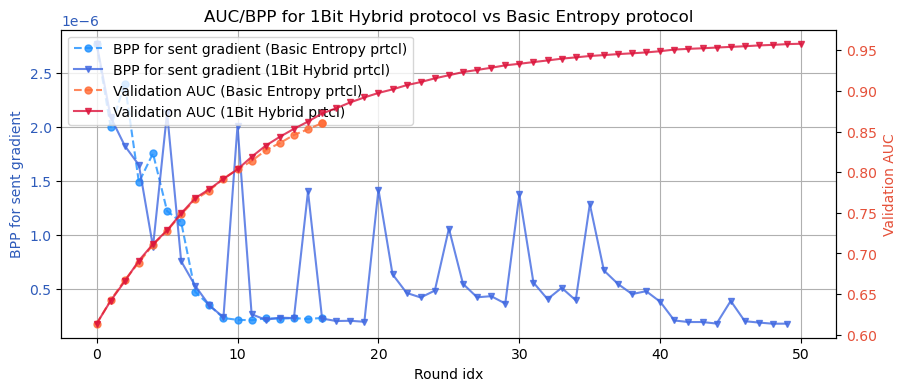

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

name = '1Bit Hybrid prtcl'
name_base = 'Basic Entropy prtcl'

model_size = 11_191_262

plt.figure(figsize=(10, 4))
ax1 = plt.gca()
temp = [name.replace('prtcl', 'protocol'), name_base.replace('prtcl', 'protocol')]
ax1.set_title(f'AUC/BPP for {temp[0]} vs {temp[1]}')

ax2 = ax1.twinx()

df_wz = pd.read_csv('wz_base.csv').groupby('round_id').mean().reset_index()
df_global = pd.read_csv('auc_base.csv')
ax2.plot(df_wz['round_id'], df_global['val_auc'].apply(lambda x: eval(x[6:])).values[:-1], label=f'Validation AUC ({name_base})', color='#FF6B35', linestyle='dashed', alpha=0.8, marker='o', markersize=5)
ax1.plot(df_wz['round_id'], df_wz['mbytes_recived']*8/model_size, label=f'BPP for sent gradient ({name_base})', color='#1E90FF', linestyle='dashed', alpha=0.8, marker='o',markersize=5)

df_wz = pd.read_csv('wz.csv').groupby('round_id').mean().reset_index()
df_global = pd.read_csv('auc.csv')
ax2.plot(df_wz['round_id'], df_global['val_auc'].apply(lambda x: eval(x[6:])).values[:-1], label=f'Validation AUC ({name})', color='#DC143C', alpha=0.8, marker='v', markersize=5)
ax1.plot(df_wz['round_id'], df_wz['mbytes_recived']*8/model_size, label=f'BPP for sent gradient ({name})', color='#4169E1', alpha=0.8, marker='v', markersize=5)

# Set separate y-axis labels and colors
ax1.set_ylabel('BPP for sent gradient', color='#2E5BBA')
ax2.set_ylabel('Validation AUC', color='#E55039')

# Set separate tick parameters for each axis
ax1.tick_params(axis='y', labelcolor='#2E5BBA')
ax2.tick_params(axis='y', labelcolor='#E55039')

ax1.set_xlabel('Round idx')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True)
plt.show()


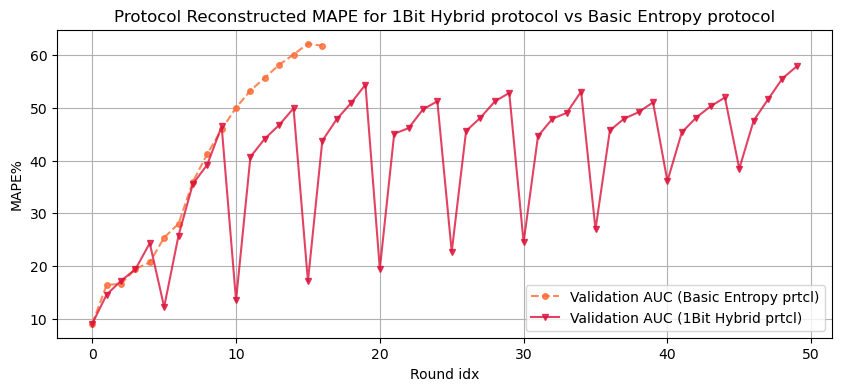

In [4]:
plt.figure(figsize=(10, 4))
plt.title(f'Protocol Reconstructed MAPE for {temp[0]} vs {temp[1]}')

df_wz = pd.read_csv('wz_base.csv').groupby('round_id').mean().reset_index()
plt.plot(df_wz['round_id'], df_wz['mape%'], label=f'Validation AUC ({name_base})', color='#FF6B35', linestyle='dashed', alpha=0.8, marker='o', markersize=4)

df_wz = pd.read_csv('wz.csv').groupby('round_id').mean().reset_index()
plt.plot(df_wz['round_id'], df_wz['mape%'], label=f'Validation AUC ({name})', color='#DC143C', alpha=0.8, marker='v', markersize=4)

plt.ylabel('MAPE%')
plt.xlabel('Round idx')
plt.legend(loc='best')
plt.grid(True)
plt.show()
